In [1]:
from sacrebleu.metrics import BLEU
import re
from itertools import combinations
import nltk
from nltk.tokenize import sent_tokenize
import os
import json
from scipy import stats
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()


In [2]:
tokenizer = nltk.data.load('tokenizers/punkt/english.pickle') # tokenizer for splitting into sentences

# Helper functions

In [3]:
# Self-BLEU function 

def calculate_self_bleu(sentences, n_gram=4):
    """
    Calculate self-BLEU scores for a set of sentences.
    
    Args:
        sentences: List of sentences to compute self-BLEU for
        n_gram: Maximum n-gram order (default: 4)
    
    Returns:
        float: Average self-BLEU score
    """

    if len(sentences) < 2:
        return "too short"
    
    # Initialize BLEU scorer
    bleu = BLEU(max_ngram_order=n_gram, effective_order=True)


    scores = []
    for i in range(len(sentences)):
        hyp = [sentences[i]]
        # Wrap each other sentence in a list → each becomes a separate reference set
        refs = [[sentences[j]] for j in range(len(sentences)) if j != i]
        score = bleu.corpus_score(hyp, refs)
        scores.append(score.score)

        #print("Hypothesis:", hyp, "References:", refs, "Score:", score.score)

    average_self_bleu = sum(scores) / len(scores)

    
        
    return average_self_bleu


In [4]:
def remove_markdown(text):
    """
    Remove markdown formatting from a sentence.
    
    Args:
        sentence: Input sentence to remove markdown from
    """

    # Remove markdown formatting
    text = re.sub(r'#+', '', text)  # Remove all # symbols
    text = re.sub(r'\*\*', '', text)  # Remove **
    text = re.sub(r'\*', '', text)  # Remove *
    return text

def is_valid_sentence(sentence):
    """
    Check if a sentence is valid (not just a number or numbered list marker)
    Returns True if sentence is valid, False otherwise
    """
    # Strip whitespace
    sentence = sentence.strip()
    
    # Check if sentence is empty
    if not sentence:
        return False
    
    # Remove common markdown formatting characters
    cleaned = sentence.replace('#', '').replace('*', '').strip()
        
    # Check if sentence is just a number followed by a period (like "1.", "2.", "### 8.", "**2.", etc)
    if cleaned.replace('.', '').isdigit():
        return False
        
    # Check if sentence is too short (less than 3 characters)
    if len(cleaned) < 3:
        return False
        
    # Check if sentence starts with a number and period but has no other content
    if cleaned.split('.')[0].isdigit() and len(cleaned.split('.')) <= 2:
        return False
    
    return True


# Calculating self-bleu for 100 responses per dataset

### Data paths

In [5]:
model_paths = {
    "Small": [
        "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/small/raw/generation_results_lora_llama_8b_single_v8.jsonl",
        "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/small/raw/generation_results_lora_llama_8b_multi_v3.jsonl",
        "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/small/raw/generation_results_lora_llama_8b_human_v3.jsonl",
        "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/small/raw/dolly_test_Llama.jsonl"
    ]
}


## Model sentences

In [69]:
def self_bleu_individual_responses_model(data_paths, output_base_dir="/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu", sample_number=500, save=False, n_gram=4, seed=42):
    """
    Calculate self-BLEU scores for individual responses from each dataset.
    
    Args:
        data_paths: Dictionary mapping model sizes to lists of file paths
        output_base_dir: Directory to save the results
        sample_number: Number of samples to use for calculation
        seed: Random seed for reproducibility
    """
    # Create output directories
    for size in ["Small", "Medium", "Large"]:
        os.makedirs(os.path.join(output_base_dir, size), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each dataset
    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        
        for file_path in tqdm(file_paths):
            # Extract model name from file path
            file_name = os.path.basename(file_path)
            model_name = file_name.split('.')[0]
            
            # Initialize data containers
            all_model_responses = []
            
            # Load the data
            with open(file_path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    response_key_model = "response_model"
                    response_model = data[response_key_model]
                    all_model_responses.append(response_model)

            clean_model_responses = []

            # Tokenize all responses
            for response_model in all_model_responses:
                response_model_sentences = sent_tokenize(response_model)
                valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
                clean_sentences = [remove_markdown(s) for s in valid_sentences]
                clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
                clean_model_responses.append(clean_sentences)

                
            indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
            response_samples = [clean_model_responses[i] for i in indices]

            self_bleu_4_scores = []
            lexical_diversity_scores = [] 

            too_short = 0

            
            for sample in response_samples:

                if len(sample) < 2:
                    too_short += 1
                    continue
                else:
                    self_bleu_4 = calculate_self_bleu(sample, n_gram)
                    lexical_diversity = 100-self_bleu_4
                    self_bleu_4_scores.append(self_bleu_4)
                    lexical_diversity_scores.append(lexical_diversity)

            average_self_bleu_4 = np.mean(self_bleu_4_scores)
            average_lexical_diversity = np.mean(lexical_diversity_scores)
            
            if save:
                # Save self-bleu scores
                model_output_file = os.path.join(output_base_dir, size, f"{model_name}_self_bleu.jsonl")
                with open(model_output_file, 'w') as f:
                    entry = {
                        "source": model_name,
                        f"average_self_bleu_{n_gram}": average_self_bleu_4,
                        "average_lexical_diversity": average_lexical_diversity,
                        "response_samples": response_samples,
                        "self_bleu_4_scores": self_bleu_4_scores,
                        "lexical_diversity_scores": lexical_diversity_scores
                    }
                    f.write(json.dumps(entry) + '\n')
                
                print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")




In [70]:
def self_bleu_all_responses_model(data_paths, output_base_dir="/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_combined", sample_number=100, save=False, n_gram=4, seed=42):
    """
    Calculate Self-BLEU scores for all model responses.
    
    Args:
        data_paths: Dictionary mapping size to list of file paths
        output_base_dir: Directory to save results
        sample_number: Number of responses to sample
        seed: Random seed for reproducibility
    """
    # Create output directories
    for size in ["Small", "Medium", "Large"]:
        os.makedirs(os.path.join(output_base_dir, size), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each dataset
    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        
        for file_path in tqdm(file_paths):
            # Extract model name from file path
            file_name = os.path.basename(file_path)
            model_name = file_name.split('.')[0]
            
            # Initialize data containers
            all_model_responses = []
            clean_model_responses = []
            
            # Load the data
            with open(file_path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    response_key_model = "response_model"
                    response_model = data[response_key_model]
                    all_model_responses.append(response_model)


            # Tokenize all responses
            for response_model in all_model_responses:
                response_model_sentences = sent_tokenize(response_model)
                valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
                clean_sentences = [remove_markdown(s) for s in valid_sentences]
                clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
                
                # Filter out responses that are too short to match with individual conditions
                if len(clean_sentences) >= 2:
                    clean_model_responses.append(clean_sentences) 
                

            # Alternative approach if you need to sample whole responses
            indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
            response_samples = [clean_model_responses[i] for i in indices]


            joined_responses = " ".join([s for sublist in response_samples for s in sublist])
            response_sentences = sent_tokenize(joined_responses)
            response_sentences = [s for s in response_sentences if len(s.split()) >= 4]


            self_bleu_4 = calculate_self_bleu(response_sentences, n_gram)
            lexical_diversity = 100-self_bleu_4



            if save: 
                # Save self-bleu scores
                model_output_file = os.path.join(output_base_dir, size, f"{model_name}_self_bleu.jsonl")
                with open(model_output_file, 'w') as f:
                    entry = {
                        "source": model_name,
                        #"self_bleu_1": self_bleu_1,
                        #"self_bleu_2": self_bleu_2,
                        #"self_bleu_3": self_bleu_3,
                        f"self_bleu_{n_gram}": self_bleu_4,
                        #"self_bleu_average": self_bleu_average,
                        "lexical_diversity": lexical_diversity,
                        "response_sentences": response_sentences
                    }
                    f.write(json.dumps(entry) + '\n')
                
                print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")




## Calculate scores

In [71]:
# Self-BLEU model scores for individual responses
save = True
n_gram = 3
sample_number = 500
output_base_dir = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/self_bleu_{n_gram}"
self_bleu_individual_responses_model(model_paths, output_base_dir, sample_number, save, n_gram)

Processing Small models...


 25%|██▌       | 1/4 [00:02<00:08,  2.83s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_3/Small/generation_results_lora_llama_8b_single_v8_self_bleu.jsonl


 50%|█████     | 2/4 [00:05<00:05,  2.72s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_3/Small/generation_results_lora_llama_8b_multi_v3_self_bleu.jsonl


 75%|███████▌  | 3/4 [00:08<00:02,  2.76s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_3/Small/generation_results_lora_llama_8b_human_v3_self_bleu.jsonl


100%|██████████| 4/4 [00:11<00:00,  2.77s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_3/Small/dolly_test_Llama_self_bleu.jsonl
All self-bleu scores have been calculated.


In [72]:
# Self-BLEU model scores for all responses

save = True
sample_number = 100
output_base_dir = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/self_bleu_combined_{n_gram}"
self_bleu_all_responses_model(model_paths, output_base_dir, sample_number, save, n_gram)

Processing Small models...


 25%|██▌       | 1/4 [01:07<03:22, 67.55s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_combined_3/Small/generation_results_lora_llama_8b_single_v8_self_bleu.jsonl


 50%|█████     | 2/4 [01:53<01:49, 54.60s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_combined_3/Small/generation_results_lora_llama_8b_multi_v3_self_bleu.jsonl


 75%|███████▌  | 3/4 [02:40<00:51, 51.09s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_combined_3/Small/generation_results_lora_llama_8b_human_v3_self_bleu.jsonl


100%|██████████| 4/4 [03:29<00:00, 52.41s/it]

  Saved self-bleu scores to /Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_combined_3/Small/dolly_test_Llama_self_bleu.jsonl
All self-bleu scores have been calculated.


# Plotting self-bleu scores

## Creating summary datasets

In [6]:
# Initialize lists to store data
n_gram = 3
self_bleu_data = []

# Process each directory
for size in ["Small"]:
    dir_path = f"/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_{n_gram}/{size}"
    
    # Process each file in the directory
    for file in os.listdir(dir_path):
        if file.endswith(".jsonl"):
            file_path = os.path.join(dir_path, file)
            
            # Read the JSONL file
            with open(file_path, 'r') as f:
                for line in f:
                    entry = json.loads(line)
                    
                    # Extract the data we need
                    self_bleu_data.append({
                        "dataset": entry["source"],
                        "size": size,
                        f"self_bleu_{n_gram}": entry[f"average_self_bleu_{n_gram}"],
                        "lexical_diversity": entry["average_lexical_diversity"],
                        "lexical_diversity_scores": entry["lexical_diversity_scores"]
                    })

# Create DataFrame
df = pd.DataFrame(self_bleu_data)

# Sort by size and source
df = df.sort_values(["size", "dataset"])
# Reset the index of the DataFrame
df = df.reset_index(drop=True)
# Assuming 'df' is your DataFrame

#df.to_pickle(f"/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_{n_gram}/self_bleu_data.pkl")
df.head(25)

,dataset,size,self_bleu_3,lexical_diversity,lexical_diversity_scores
0,dolly_test_Llama,Small,25.159921,74.840079,"[64.75269661138651, 69.70113383302231, 70.2134..."
1,generation_results_lora_llama_8b_human_v3,Small,24.913800,75.086200,"[83.7127643903903, 38.84526846796634, 90.26510..."
2,generation_results_lora_llama_8b_multi_v3,Small,25.228594,74.771406,"[77.05460203419268, 97.3464177411695, 68.79807..."
3,generation_results_lora_llama_8b_single_v8,Small,26.006209,73.993791,"[76.47834388284386, 91.58239422499813, 67.3748..."


In [7]:
# SELF BLEU COMBINED
# Initialize lists to store data
n_gram = 3
self_bleu_data_combined = []

# Process each directory
for size in ["Small"]:
    dir_path = f"/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_combined_{n_gram}/{size}"
    
    # Process each file in the directory
    for file in os.listdir(dir_path):
        if file.endswith(".jsonl"):
            file_path = os.path.join(dir_path, file)
            
            # Read the JSONL file
            with open(file_path, 'r') as f:
                for line in f:
                    entry = json.loads(line)
                    
                    # Extract the data we need
                    self_bleu_data_combined.append({
                        "dataset": entry["source"],
                        "size": size,
                        f"self_bleu_{n_gram}": entry[f"self_bleu_{n_gram}"],
                        "lexical_diversity": entry["lexical_diversity"],
                    })

# Create DataFrame
df_combined = pd.DataFrame(self_bleu_data_combined)

# Sort by size and source
df_combined = df_combined.sort_values(["size", "dataset"])
# Reset the index of the DataFrame
df_combined = df_combined.reset_index(drop=True)
#df_combined.to_pickle(f"/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/self_bleu_combined_{n_gram}/{size}/self_bleu_combined_data.pkl")
df_combined.head(25)

,dataset,size,self_bleu_3,lexical_diversity
0,dolly_test_Llama,Small,44.010094,55.989906
1,generation_results_lora_llama_8b_human_v3,Small,41.993422,58.006578
2,generation_results_lora_llama_8b_multi_v3,Small,43.084116,56.915884
3,generation_results_lora_llama_8b_single_v8,Small,45.376032,54.623968


## Load data

## Plot

### Summary plot

In [8]:
df_individual.head(10)
#df_aggregated.head(10)

,dataset,size,self_bleu_3,lexical_diversity,lexical_diversity_scores
0,dolly_test_Llama,Small,25.159921,74.840079,"[64.75269661138651, 69.70113383302231, 70.2134..."
1,generation_results_lora_llama_8b_human_v3,Small,24.913800,75.086200,"[83.7127643903903, 38.84526846796634, 90.26510..."
2,generation_results_lora_llama_8b_multi_v3,Small,25.228594,74.771406,"[77.05460203419268, 97.3464177411695, 68.79807..."
3,generation_results_lora_llama_8b_single_v8,Small,26.006209,73.993791,"[76.47834388284386, 91.58239422499813, 67.3748..."


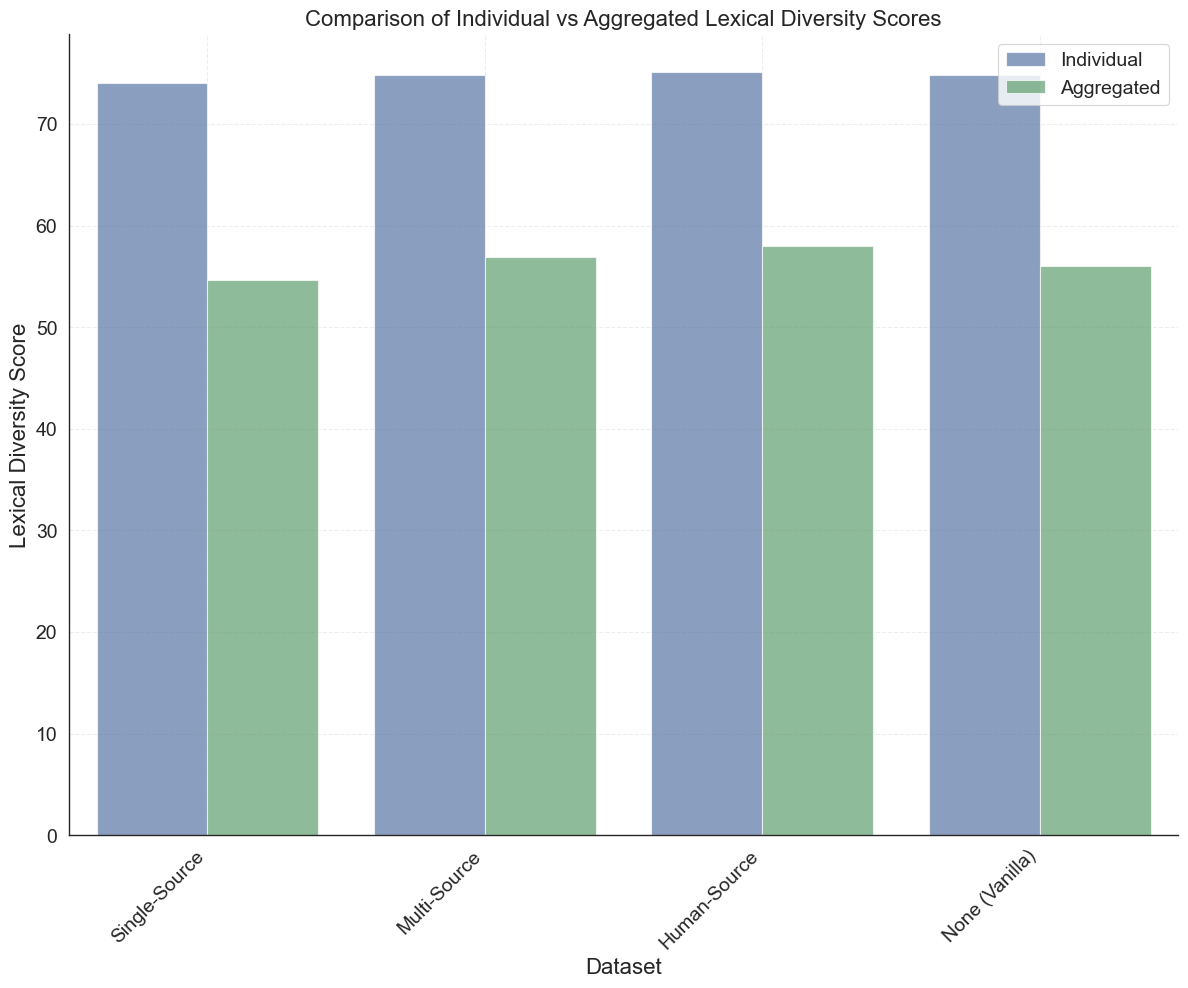

In [14]:
df_individual = pd.read_pickle(f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/self_bleu_3/self_bleu_data.pkl")
df_aggregated = pd.read_pickle(f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/self_bleu_combined_3/Small/self_bleu_combined_data.pkl")

plt.figure(figsize=(12, 10))

# Create a grouped bar plot 
sns.barplot(
    data=pd.concat([
        df_individual.assign(type='Individual'),
        df_aggregated.assign(type='Aggregated')
    ]).sort_values('dataset', ascending=False),  # Sort datasets in reverse order
    x='dataset',
    y='lexical_diversity',
    hue='type',
    alpha=0.7,
)

# Customize the plot with larger font sizes
plt.xlabel('Dataset', fontsize=16)
plt.ylabel('Lexical Diversity Score', fontsize=16)
plt.title('Comparison of Individual vs Aggregated Lexical Diversity Scores', fontsize=16)

# Set custom x-tick labels
plt.xticks(
    ticks=range(4),  # Assuming 4 datasets
    labels=['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    rotation=45,
    ha='right',
    fontsize=14
)
plt.yticks(fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Increase legend font size
plt.legend(fontsize=14)

# Adjust layout to prevent label cutoff
plt.tight_layout()

#plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lexical_div/bar_lex_div_individual_aggregated_v2.png")

# Show the plot
plt.show()


In [17]:
# Reverse the order of rows in both dataframes
df_individual = df_individual.iloc[::-1].reset_index(drop=True)
df_aggregated = df_aggregated.iloc[::-1].reset_index(drop=True)

,dataset,size,self_bleu_3,lexical_diversity
0,generation_results_lora_llama_8b_single_v8,Small,45.376032,54.623968
1,generation_results_lora_llama_8b_multi_v3,Small,43.084116,56.915884
2,generation_results_lora_llama_8b_human_v3,Small,41.993422,58.006578
3,dolly_test_Llama,Small,44.010094,55.989906


In [23]:
#dataset_names = ["Vanilla", "Human-tuned", "Multi-source tuned", "Single-source tuned"]
dataset_names = ["Single-Source", "Multi-Source", "Human-Source", "None (Vanilla)"]

lex_div_scores = [scores for scores in df_individual['lexical_diversity_scores']]

# Calculate and display statistics
print("Lexical Diversity Statistics:")
print("-" * 50)
for i, (name, perplexities) in enumerate(zip(dataset_names, lex_div_scores)):
    mean = np.mean(perplexities)
    variance = np.var(perplexities)
    print(f"{name}:")
    print(f"  Mean: {mean:.4f}")
    print(f"  Variance: {variance:.4f}")
    print(f"  Standard Deviation: {np.sqrt(variance):.4f}")
    print()


Lexical Diversity Statistics:
--------------------------------------------------
Single-Source:
  Mean: 73.9938
  Variance: 227.0310
  Standard Deviation: 15.0675

Multi-Source:
  Mean: 74.7714
  Variance: 233.5037
  Standard Deviation: 15.2808

Human-Source:
  Mean: 75.0862
  Variance: 214.4862
  Standard Deviation: 14.6453

None (Vanilla):
  Mean: 74.8401
  Variance: 242.6702
  Standard Deviation: 15.5779



In [20]:
# Perform Levene's test
statistic, p_value = stats.levene(*lex_div_scores)

print("\nLevene's Test for Homogeneity of Variances:")
print("-" * 50)
print(f"Test Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.4e}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nThe differences in variance between datasets are statistically significant")
    print("(p < 0.05)")
else:
    print("\nThe differences in variance between datasets are not statistically significant")
    print("(p >= 0.05)")

# Perform pairwise Levene's tests
print("\nPairwise Levene's Tests:")
print("-" * 50)
for i in range(len(dataset_names)):
    for j in range(i+1, len(dataset_names)):
        stat, p_val = stats.levene(lex_div_scores[i], lex_div_scores[j])
        print(f"{dataset_names[i]} vs {dataset_names[j]}:")
        print(f"  p-value: {p_val:.4e}")
        if p_val < alpha:
            print("  Significant difference in variance")
        else:
            print("  No significant difference in variance")
        print()



Levene's Test for Homogeneity of Variances:
--------------------------------------------------
Test Statistic: 0.7451
p-value: 5.2520e-01

The differences in variance between datasets are not statistically significant
(p >= 0.05)

Pairwise Levene's Tests:
--------------------------------------------------
Single-Source vs Multi-Source:
  p-value: 6.9808e-01
  No significant difference in variance

Single-Source vs Human-Source:
  p-value: 9.8677e-01
  No significant difference in variance

Single-Source vs None (Vanilla):
  p-value: 1.9916e-01
  No significant difference in variance

Multi-Source vs Human-Source:
  p-value: 6.9979e-01
  No significant difference in variance

Multi-Source vs None (Vanilla):
  p-value: 3.7625e-01
  No significant difference in variance

Human-Source vs None (Vanilla):
  p-value: 1.8862e-01
  No significant difference in variance



In [21]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
H, p_value = stats.kruskal(*lex_div_scores)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(dataset_names)):
        for j in range(i + 1, len(dataset_names)):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 1.02
p-value: 7.96e-01


### Individual models

In [36]:
n_gram = 3

self_bleu_data = pd.read_pickle(f"../../Data/analysis/self_bleu_{n_gram}/self_bleu_data.pkl")
self_bleu_data_combined = pd.read_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/self_bleu_combined_data.pkl")

# Define the order for size categories
size_order = ["Human", "Small", "Medium", "Large"]

# Convert 'size' column to categorical type with the specified order
self_bleu_data['size'] = pd.Categorical(self_bleu_data['size'], categories=size_order, ordered=True)
self_bleu_data_combined['size'] = pd.Categorical(self_bleu_data_combined['size'], categories=size_order, ordered=True)

# Sort the dataframes by 'size'
self_bleu_data = self_bleu_data.sort_values('size')
self_bleu_data_combined = self_bleu_data_combined.sort_values('size')

# Reset the index of self_bleu_data
self_bleu_data.reset_index(drop=True, inplace=True)
self_bleu_data_combined.reset_index(drop=True, inplace=True)

self_bleu_data.at[10, 'model'] = 'Qwen'
self_bleu_data_combined.at[10, 'model'] = 'Qwen'

# Swap the row at index 11 with that at index 17
self_bleu_data.iloc[[11, 17]] = self_bleu_data.iloc[[17, 11]].values

self_bleu_data_combined.head(25)


,dataset,model,size,self_bleu_3,lexical_diversity
0,dolly_train_1,Human,Human,27.817671,72.182329
1,dolly_train_2,Human,Human,24.425078,75.574922
2,dolly_train_3,Human,Human,24.936844,75.063156
3,dolly_train_4,Human,Human,26.067974,73.932026
4,dolly_train_3,Llama,Small,46.347424,53.652576
5,dolly_train_2,Llama,Small,44.595332,55.404668
6,dolly_train_1,Llama,Small,43.223165,56.776835
7,dolly_train_2,Gemma,Small,30.728718,69.271282
8,dolly_train_4,Falcon,Small,33.136307,66.863693
9,dolly_train_4,Llama,Small,43.809057,56.190943


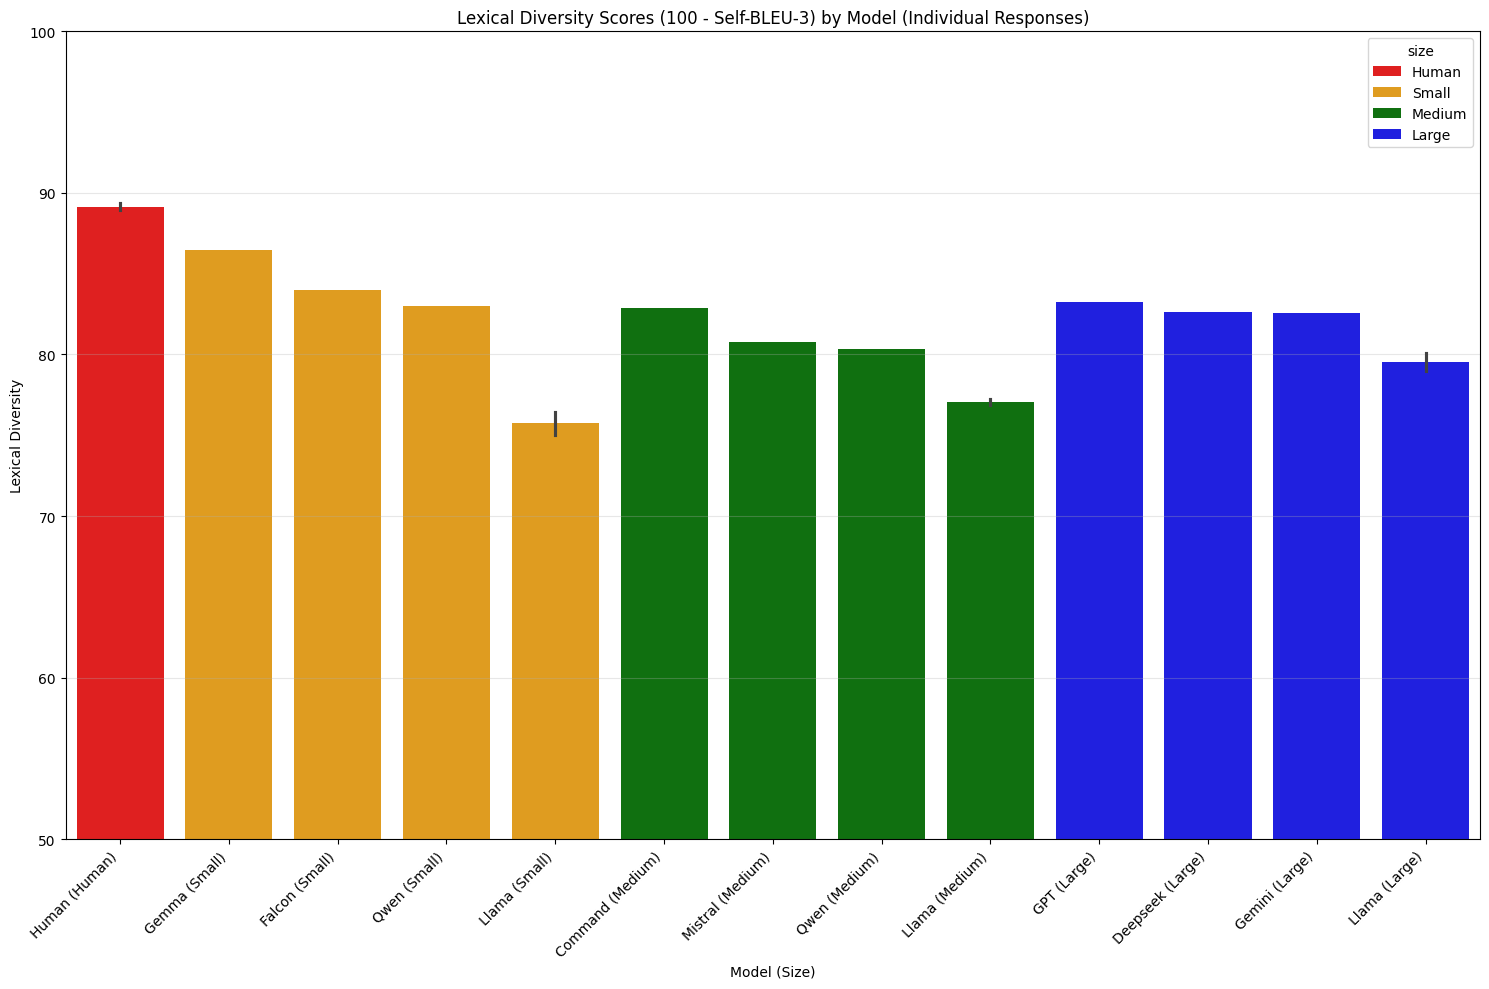

In [37]:
# Create a plot to visualize self_bleu scores by model, split by size
plt.figure(figsize=(15, 10))
plt.grid(True, linestyle='-', alpha=0.3)

# Add a new column to combine model name and size
self_bleu_data['model_with_size'] = self_bleu_data['model'] + ' (' + self_bleu_data['size'].astype(str) + ')'

# Define a custom color palette for the sizes
size_palette = {
    "Human": "red",
    "Small": "orange",
    "Medium": "green",
    "Large": "blue"
}

# Sort the data within each size by lexical diversity score in descending order
self_bleu_data_sorted = self_bleu_data.sort_values(by=['size', 'lexical_diversity'], ascending=[True, False])

# Create the bar plot with color according to size category
sns.barplot(
    data=self_bleu_data_sorted,
    x='model_with_size',
    y='lexical_diversity',
    hue='size',  # Use 'size' for color coding
    palette=size_palette,
    dodge=False  # Ensure bars are not dodged
)

plt.title(f"Lexical Diversity Scores (100 - Self-BLEU-{n_gram}) by Model (Individual Responses)")
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(0, 101, 10))
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)
plt.ylabel("Lexical Diversity")
plt.xlabel("Model (Size)")
plt.ylim(50, 100)
plt.tight_layout()
plt.show()


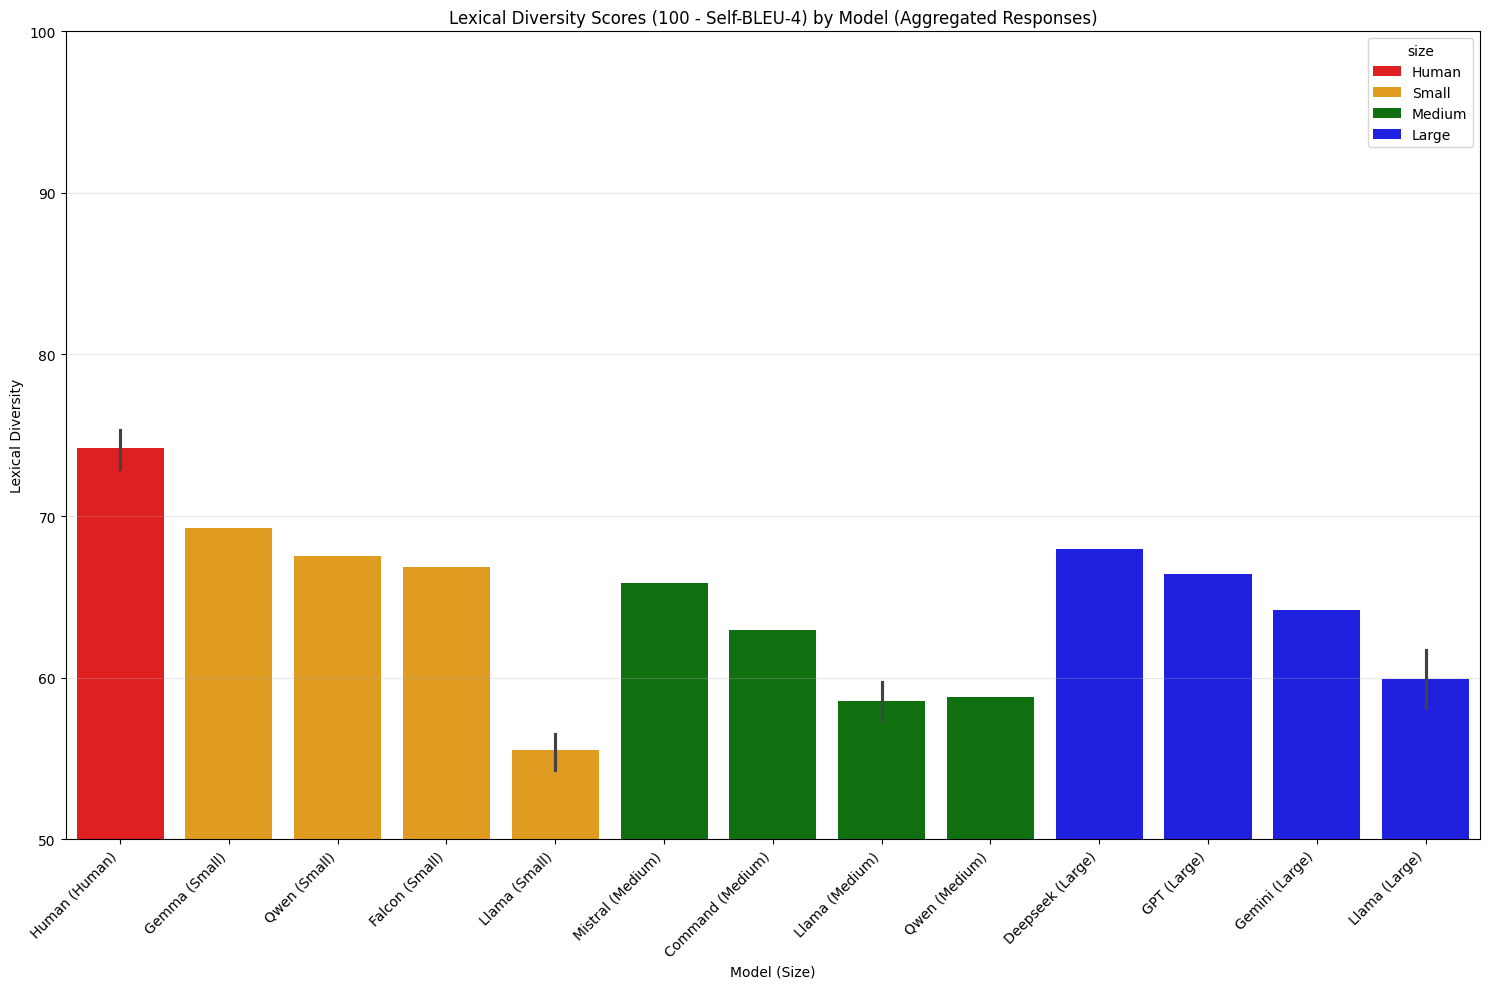

In [39]:
n_gram = 4

# Create a plot to visualize self_bleu scores by model, split by size
plt.figure(figsize=(15, 10))
plt.grid(True, linestyle='-', alpha=0.3)

# Add a new column to combine model name and size
self_bleu_data_combined['model_with_size'] = self_bleu_data_combined['model'] + ' (' + self_bleu_data_combined['size'].astype(str) + ')'

# Define a custom color palette for the sizes
size_palette = {
    "Human": "red",
    "Small": "orange",
    "Medium": "green",
    "Large": "blue"
}

# Sort the data within each size by lexical diversity score in descending order
self_bleu_data_combined_sorted = self_bleu_data_combined.sort_values(by=['size', 'lexical_diversity'], ascending=[True, False])

# Create the bar plot with color according to size category
sns.barplot(
    data=self_bleu_data_combined_sorted,
    x='model_with_size',
    y='lexical_diversity',
    hue='size',  # Use 'size' for color coding
    palette=size_palette,
    dodge=False  # Ensure bars are not dodged
)

plt.title(f"Lexical Diversity Scores (100 - Self-BLEU-{n_gram}) by Model (Aggregated Responses)")
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(0, 101, 10))
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)
plt.ylabel("Lexical Diversity")
plt.xlabel("Model (Size)")
plt.ylim(50, 100)
plt.tight_layout()
plt.show()


# Calculate self-BLEU scores for gemini with and without system prompts


Comparison of Gemini with and without system prompt:
         dataset               model   size  self_bleu_3  lexical_diversity
0  dolly_train_2              Gemini  Large    18.421606          81.578394
1  dolly_train_2  Gemini_with_system  Large    17.088087          82.911913


/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_61754/670297365.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


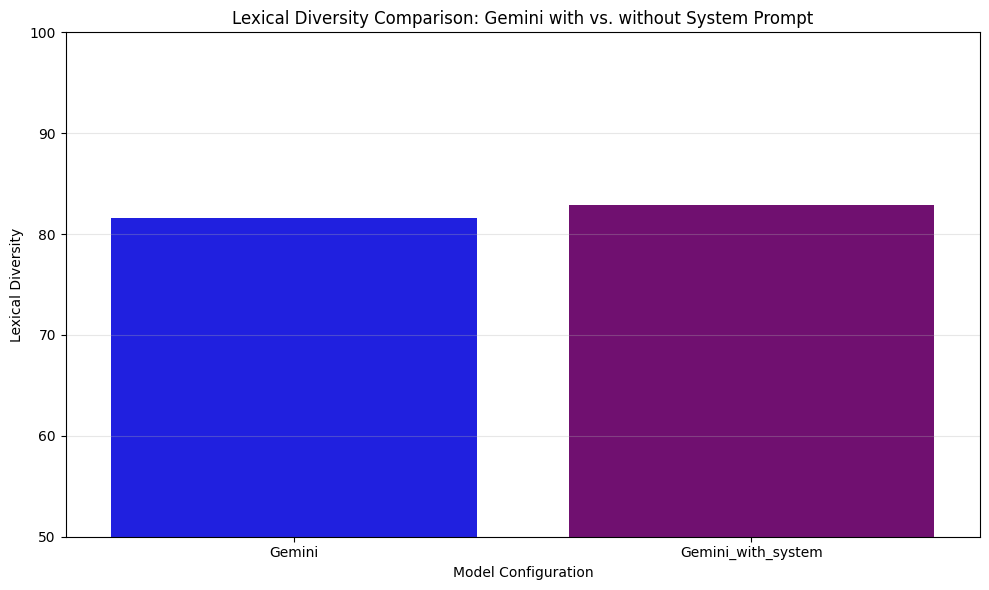

In [9]:
n_gram = 3

# Load the Gemini datasets with and without system prompts
gemini_without_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl"
gemini_with_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini_with_system_prompt.jsonl"

# Function to load and process the data
def load_jsonl_data(file_path, sample_number=500):
    all_model_responses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
            response_model = data[response_key_model]
            all_model_responses.append(response_model)


    clean_model_responses = []

    # Tokenize all responses
    for response_model in all_model_responses:
        response_model_sentences = sent_tokenize(response_model)
        valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
        clean_sentences = [remove_markdown(s) for s in valid_sentences]
        clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
        clean_model_responses.append(clean_sentences) 
        
    indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
    response_samples = [clean_model_responses[i] for i in indices]
            
    return response_samples


gemini_without_system_responses = load_jsonl_data(gemini_without_system)
gemini_with_system_responses = load_jsonl_data(gemini_with_system)

self_bleu_4_scores_without_system = []
self_bleu_4_scores_with_system = []
lexical_diversity_scores_without_system = [] 
lexical_diversity_scores_with_system = [] 

too_short = 0

for sample1, sample2 in zip(gemini_without_system_responses, gemini_with_system_responses):

    if len(sample1) < 2:
        too_short += 1
        continue
    elif len(sample2) < 2:
        too_short += 1
        continue
    else:
        self_bleu_4 = calculate_self_bleu(sample1, n_gram)
        lexical_diversity = 100-self_bleu_4
        self_bleu_4_scores_without_system.append(self_bleu_4)
        lexical_diversity_scores_without_system.append(lexical_diversity)

        self_bleu_4 = calculate_self_bleu(sample2, n_gram)
        lexical_diversity = 100-self_bleu_4
        self_bleu_4_scores_with_system.append(self_bleu_4)
        lexical_diversity_scores_with_system.append(lexical_diversity)



average_self_bleu_without_system = np.mean(self_bleu_4_scores_without_system)
average_self_bleu_with_system = np.mean(self_bleu_4_scores_with_system)

average_lexical_diversity_without_system = np.mean(lexical_diversity_scores_without_system)
average_lexical_diversity_with_system = np.mean(lexical_diversity_scores_with_system)
    


# Create a DataFrame to compare the results
gemini_comparison = pd.DataFrame({
    'dataset': ['dolly_train_2', 'dolly_train_2'],
    'model': ['Gemini', 'Gemini_with_system'],
    'size': ['Large', 'Large'],
    'self_bleu_' + str(n_gram): [average_self_bleu_without_system, average_self_bleu_with_system],
    'lexical_diversity': [average_lexical_diversity_without_system, average_lexical_diversity_with_system]
})

print("\nComparison of Gemini with and without system prompt:")
print(gemini_comparison)

# Visualize the comparison
plt.figure(figsize=(10, 6))
plt.grid(True, linestyle='-', alpha=0.3)

sns.barplot(
    data=gemini_comparison,
    x='model',
    y='lexical_diversity',
    palette=['blue', 'purple']
)

plt.title(f"Lexical Diversity Comparison: Gemini with vs. without System Prompt")
plt.ylabel("Lexical Diversity")
plt.xlabel("Model Configuration")
plt.ylim(50, 100)
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()



Comparison of Gemini with and without system prompt:
         dataset               model   size  self_bleu_3  lexical_diversity
0  dolly_train_2              Gemini  Large    18.421606          81.578394
1  dolly_train_2  Gemini_with_system  Large    17.088087          82.911913


/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_61754/4032037436.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


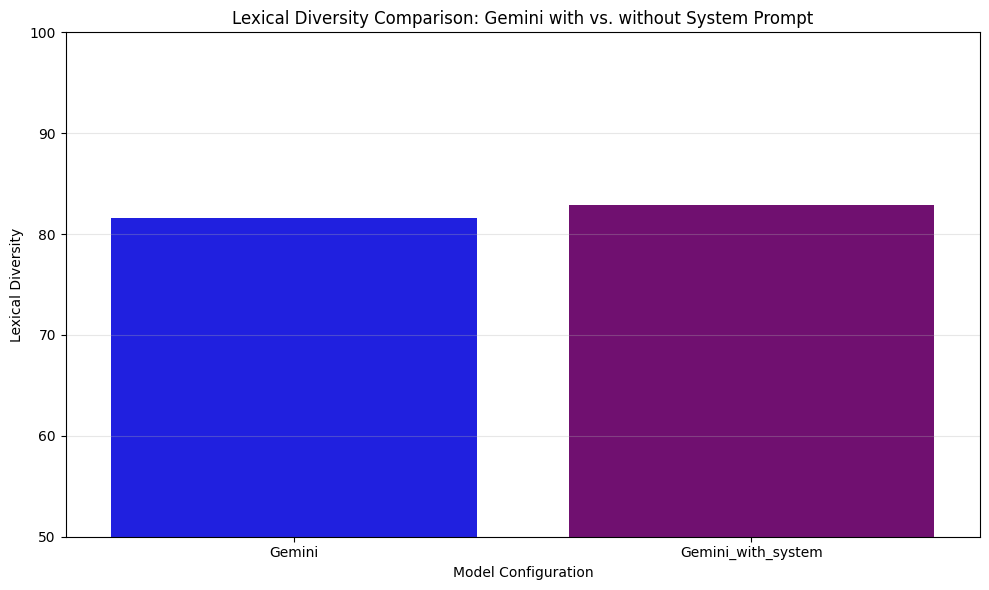

In [ ]:
n_gram = 3

# Load the Gemini datasets with and without system prompts
gemini_without_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl"
gemini_with_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini_with_system_prompt.jsonl"

# Function to load and process the data
def load_jsonl_data(file_path, sample_number=100):
    all_model_responses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
            response_model = data[response_key_model]
            all_model_responses.append(response_model)


    clean_model_responses = []

    # Tokenize all responses
    for response_model in all_model_responses:
        response_model_sentences = sent_tokenize(response_model)
        valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
        clean_sentences = [remove_markdown(s) for s in valid_sentences]
        clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
        clean_model_responses.append(clean_sentences) 
        
    indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
    response_samples = [clean_model_responses[i] for i in indices]
            
    return response_samples


gemini_without_system_responses = load_jsonl_data(gemini_without_system)
gemini_with_system_responses = load_jsonl_data(gemini_with_system)

self_bleu_4_scores_without_system = []
self_bleu_4_scores_with_system = []
lexical_diversity_scores_without_system = [] 
lexical_diversity_scores_with_system = [] 


sentences_gemini_without_system = [sentence for sample in gemini_without_system_responses for sentence in sample]
sentences_gemini_with_system = [sentence for sample in gemini_with_system_responses for sentence in sample]



self_bleu_4_without_system = calculate_self_bleu(sentences_gemini_without_system, n_gram)
lexical_diversity_without_system = 100-self_bleu_4_without_system

self_bleu_4_with_system = calculate_self_bleu(sentences_gemini_with_system, n_gram)
lexical_diversity_with_system = 100-self_bleu_4_with_system
    



# Visualize the comparison
plt.figure(figsize=(10, 6))
plt.grid(True, linestyle='-', alpha=0.3)

sns.barplot(
    data=gemini_comparison,
    x='model',
    y='lexical_diversity',
    palette=['blue', 'purple']
)

plt.title(f"Lexical Diversity Comparison: Gemini with vs. without System Prompt")
plt.ylabel("Lexical Diversity")
plt.xlabel("Model Configuration")
plt.ylim(50, 100)
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# Create a DataFrame to compare the results
gemini_comparison = pd.DataFrame({
    'dataset': ['dolly_train_2', 'dolly_train_2'],
    'model': ['Gemini', 'Gemini_with_system'],
    'size': ['Large', 'Large'],
    'self_bleu_' + str(n_gram): [self_bleu_4_without_system, self_bleu_4_with_system],
    'lexical_diversity': [lexical_diversity_without_system, lexical_diversity_with_system]
})

print("\nComparison of Gemini with and without system prompt:")
print(gemini_comparison)


Comparison of Gemini with and without system prompt:
         dataset               model   size  self_bleu_3  lexical_diversity
0  dolly_train_2              Gemini  Large    31.634950          68.365050
1  dolly_train_2  Gemini_with_system  Large    33.815012          66.184988
